# Hypothesis testing for a proportion

---

#### Summary videos

- [Inference for proportions](https://youtu.be/PUMBNtVKr_g?si=GyWi4793EFxOmEyy) (5 minutes)
- [Hypothesis testing fundamentals](https://youtu.be/NVbPE1_Cbx8?si=r7ejBtBNYbTjdJ1R) (8 minutes)

#### Walkthrough videos

- [Hypothesis testing framework](https://drive.google.com/file/d/1_145Ozn4ATldXO6NTQzKgBo0PC0Bt-4U/view?usp=sharing) (11 minutes)
- [Statistical inference with confidence intervals](https://drive.google.com/file/d/1dtYtjbLQnlrP5-KisYmAzqO9-wfJuka6/view?usp=sharing) (17 minutes)
- [Decision errors](https://drive.google.com/file/d/1gkDVZV-4RCBTVWD9tUr-R4wgv_uywK9C/view?usp=sharing) (7 minutes)
- [Formal testing using p-values](https://drive.google.com/file/d/1-ACkMA9OLrLQr6UVm-ArMrdHRzenemV4/view?usp=sharing) (19 minutes)
- [One-sided hypothesis tests](https://drive.google.com/file/d/17YD0LLmFaXQrGONttqJVNvpYWjZrM_tc/view?usp=sharing) (5 minutes)

---

The following is a question from Ola Rosling's *Factfulness.*

> How many of the world's 1 year old children today have been vaccinated against some disease?
>
> a. 20%
>
> b. 50%
>
> c. 80%

How well do you think the average college graduate might do in answering this question?

## Hypothesis testing framework

Taking the role of a skeptic, I might propose the following **null hypothesis**.

> $H_0$: People don't learn about these sorts of world health issues in college, so their responses to this question are equivalent to random guesses.

### Exercise

Assuming the null hypothesis, what proportion of people responding to Rosling's question should get the answer correct?

> Note, the value of the parameter in the null hypothesis is sometimes called the **null value** and may even be denoted $p_0$.

The alternative to the null hypothesis is called the **alternative hypothesis**, $H_A$.

### Exercise

- Describe the alternative hypothesis corresponding to our null hypothesis above.
- Is there a specific value of the parameter associated to the alternative hypothesis?

### Innocent until proven guilty
In the U.S. court system, defendants are presumed innocent until proven guilty. The prosecution will present evidence to the jury in an attempt to convince them beyond a reasonable doubt that the defendant is guilty (i.e., not innocent).

* Which of `innocent` or `guilty` is the null hypothesis?
* If the prosecution is not able to present strong enough evidence of guilt to the jury, does that mean the defendant is truly innocent?
* If we fail to reject the null hypothesis, is that the same thing as accepting the null hypothesis as true?

## Testing hypotheses using confidence intervals

Does the actual data provide strong enough evidence to convince us that the proportion of college-educated adults who can answer Rosling's question correctly is *not* 33.3%?

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

rosling_responses = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/rosling_responses.csv')
rosling_responses.head()

In [ ]:
rosling_responses.tail()

The data set contains data on more than one question, so we'll pick out the data related to our child vaccinations above.

In [ ]:
child_vacc = rosling_responses[rosling_responses['question'] == 'children_with_1_or_more_vaccination']
child_vacc.shape

It looks like our sample has 50 responses to this question. What is the sample proportion of *correct* responses?

In [ ]:
sum(child_vacc['response'] == 'correct') / 50

24% is certainly not the same thing as the null value, 33.3%. However, as we've learned previously, sample statistics will naturally vary from the true population parameter values.

Is is reasonable to suspect that the deviation of 24% from 33.3% simply due to chance? Or, is 24% different enough from 33.3% in this situation to warrant our attention?


### Example

We can use confidence intervals to determine whether or not 33.3% is within a plausible range of values for the true paramater $p$.

* Verify the conditions of the CLT for this sampling distribution in order to conlude that the sampling distribution is (nearly) normal.

  * Use $\hat{p}$ in place of the true proportion, $p$.

* Construct a 95% confidence interval using the point estimate of $\hat{p} = 24\%$.

* Determine whether we should reject the null hypothesis or if we have failed to reject the null hypothesis.

In [ ]:
# 95% confidence interval

# Input the values
p_hat = 0.24
z_star = 1.96
se = 0.06

# Compute the lower and upper bounds of the confidence interval
lower = round(p_hat - z_star * se, 4)
upper = round(p_hat + z_star * se, 4)

# Print the results
print(f"95% Confidence Interval: ({lower},{upper})")

### Example

The other question with responses in this data set is the following.

> There are 2 billion children in the world today aged 0–15 years old. How many children will there be in 2100?
>
> a. 4 billion
>
> b. 3 billion
>
> c. 2 billion

Use a 95% confidence interval to determine whether college-educated adults are better than random guessing on this question.

In [ ]:
child_2100 = rosling_responses[rosling_responses['question'] == 'children_in_2100']
child_2100.shape

In [ ]:
p_hat = sum(child_2100['response'] == 'correct') / 228
print(p_hat)

Use `p_hat` to estimate the standard error and determine a 95% confidence interval to make a conclusion regarding the hypotheses.

In [ ]:
# This code uses the `math` package to compute the standard error for us!

import math

p_hat = sum(child_2100['response'] == 'correct') / 228
z_star = 1.96
se = math.sqrt((p_hat * (1 - p_hat))/228)

print(f"95% confidence interval: ({round(p_hat - z_star * se, 4)},{round(p_hat + z_star * se, 4)})")


## Decision errors

### Question
Do you think our decision to reject or fail to reject the null hypothesis could be affected by the confidence level used?

Hypothesis testing is not perfect. Below is a table summarizing the two types of errors possible in hypothesis testing, from page 193 of the textbook.

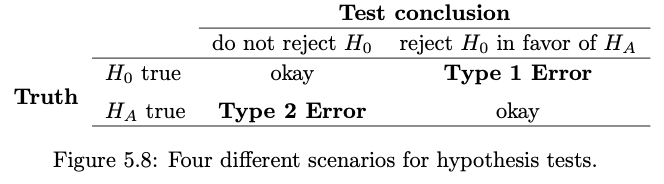

### Exercise

* In the court system analogy, what would a Type 1 Error be?
* What about a Type 2 Error?

### Question

Which type of error do think is more important to avoid?

As a general guideline, we don't want to commit a Type 1 error more than 5% of the time. This corresponds to a **significance level** of $\alpha = 0.05$ (or 5%). This, in turn, would correspond to a confidence level of

$$ 1 - \alpha = 1 - 0.05 = 0.95 = 95\%. $$

The significance level is often denoted $\alpha$ and it measures how strong our evidence needs to be to reject the null hypothesis. **The lower the significance level, the more convincing the evidence needs to be to reject the null hypothesis.**

> [Click here](https://openintro.org/book/stat/why05/) for a short exercise to explore *why* 0.05 is often used as a significance level.

## Formal testing using p-values

### Example 5.28–5.32
Pew Research sampled 1000 Americans regarding whether they were in favor of increasing the use of coal as an energy source.

* Set up hypotheses to test whether a majority of American adults support or oppose an increased use of coal.

* Pew Research's sample found 37% of American adults in favor of increasing the use of coal. Does 37% represent a **significant** difference from the null hypothesis?
  * Make your conclusion using a **p-value** (as opposed to a confidence interval) with significance level $\alpha = 0.05$.
  * Is this notion of **statistical significance** the same thing as **practical significance**?

In [ ]:
# Run this code to double-check the results of the hypothesis test.

import math
import scipy.stats as stats

alpha = 0.05
p_null = 0.5

p_hat = 0.37
n = 1000

SE = round(math.sqrt((p_null * (1 - p_null))/n), 3)

Z_score = round((p_hat - p_null)/SE, 3)

p_value = 2*(1 - stats.norm.cdf(abs(Z_score), loc = 0, scale = 1))

print(f"Z-score: {Z_score}")
print(f"p-value: {p_value}")

if p_value < alpha:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

### p-values
The **p-value** is the probability of observing data at least as favorable to the alternative hypothesis as our current data set, assuming the null hypothesis is true.

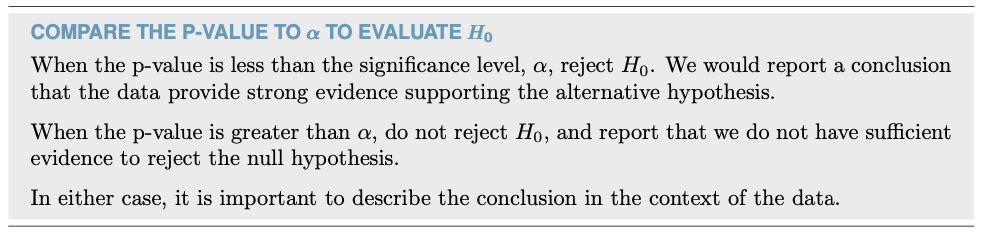

## One-sided hypothesis tests

The examples above deal with what is sometimes called a **two-sided hypothesis test**, since determining the p-value requires us to consider tail areas on two sides of a normal distribution.

For a two-sided hypothesis test, we have
* $H_0$: $p = p_0$
* $H_A$: $p \neq p_0.$

In a one-sided hypothesis test, we are only interested in determining if the population parameter differs from $p_0$ in *one* direction. In these tests, $H_A$ takes the form of either $p > p_0$ or $p < p_0$.

One should use caution before utilizing a one-sided test, as in the next example from page 200 of the textbook.

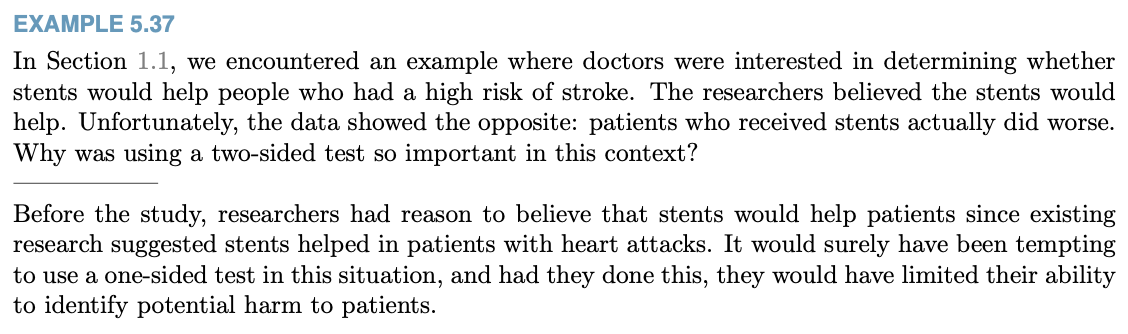

Two-sided tests tend to be more common than one-sided tests. Part of the reason behind this is how a one-sided test alters the relationship between p-value and significance level. In particular, performing a one-sided test essentially results in doubling the significance level.

### Exercise

Use [GeoGebra](https://www.geogebra.org/classic#probability) to visualize the difference in area under a normal curve between two-sided and one-sided tests.

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.